In [1]:
import cv2
import matplotlib.pyplot as plt

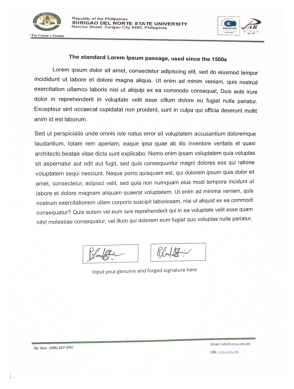

In [2]:
# Load image
img = cv2.imread("doc.jpg")

# Convert from BGR (OpenCV format) to RGB (for display)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Show inline
plt.imshow(img_rgb)
plt.axis('off')
plt.show()

In [5]:
def horizontal_vertical_lines_detection(binary):
    """
    args
        binary: accept an image binary

    ret
        returns combination of horizontal and vetical dilate
    """
    # --- Detect horizontal lines ---
    horizontal = binary.copy()
    cols = horizontal.shape[1]
    horizontal_size = cols // 30  # tune this (bigger = fewer detections)
    horizontal_structure = cv2.getStructuringElement(cv2.MORPH_RECT, (horizontal_size, 1))
    horizontal = cv2.erode(horizontal, horizontal_structure)
    horizontal = cv2.dilate(horizontal, horizontal_structure)
    
    # --- Detect vertical lines ---
    vertical = binary.copy()
    rows = vertical.shape[0]
    vertical_size = rows // 30
    vertical_structure = cv2.getStructuringElement(cv2.MORPH_RECT, (1, vertical_size))
    vertical = cv2.erode(vertical, vertical_structure)
    vertical = cv2.dilate(vertical, vertical_structure)

    mask = horizontal + vertical
    return mask

def find_contours(mask, img):
    contours, hierarchy = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    h, w = img.shape[:2]

    # Define margins to ignore header/footer
    top_margin = int(h * 0.10)      # ignore top 10% of the page
    bottom_margin = int(h * 0.90)   # ignore bottom 10% of the page

    for c in contours:
        x, y, bw, bh = cv2.boundingRect(c)

        # Skip very small boxes
        if bw < 20 or bh < 20:
            continue

        # Skip header/footer regions
        if y < top_margin or y + bh > bottom_margin:
            continue

        # Draw box if it's within valid region
        cv2.rectangle(img, (x, y), (x + bw, y + bh), (0, 0, 255), 2)

    return img

def detect_box(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    binary = cv2.adaptiveThreshold(
        ~gray, 255,
        cv2.ADAPTIVE_THRESH_MEAN_C,
        cv2.THRESH_BINARY,
        15, -2
    )

    mask = horizontal_vertical_lines_detection(binary)
    f_c = find_contours(mask, img)
    
    return f_c

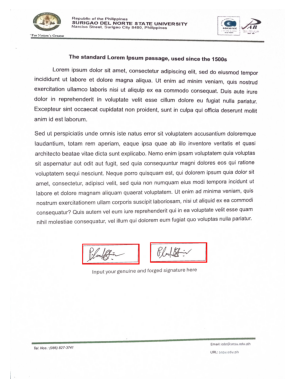

In [8]:
result = detect_box(img)

# Show inline
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()